## 1. Exploration du dataset (EDA)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_brute = pd.read_parquet(r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\archive (1)\Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet")
df_brute.head(5)

In [61]:
import re
df_infi = pd.read_parquet(r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\archive (1)\Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet")
df_infi.head(5)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,94658,6,7,708,3718,387,0,118.0,159.284653,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,206,2,0,0,0,0,0,0.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,165505,3,1,0,0,0,0,0.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,102429,6,7,708,3718,387,0,118.0,159.284653,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,167,2,0,0,0,0,0,0.0,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [ ]:
df_brute.columns

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Fla

In [ ]:
df_brute.columns.size

78

In [44]:
#lire le fichier paquet avec un dataframe et afficher les 5 premiers lignes
df_ddos = pd.read_parquet(r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\archive (1)\DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet")
df_ddos.head(5)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,888751,11,11,1249,1969,736,0,113.545456,220.896072,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
1,0,112642816,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56300000.0,7.071068,56300000,56300000,Benign
2,0,112642712,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56300000.0,18.384777,56300000,56300000,Benign
3,0,112642648,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56300000.0,5.656854,56300000,56300000,Benign
4,0,112642702,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56300000.0,65.053825,56300000,56300000,Benign


In [ ]:
#afficher les noms des colonnes dans le datafram
print("noms des colonnes",df_ddos.columns)
# retourner nombre de colonne
nbr_clmns = df_ddos.columns.size
print("nombre de colonnes est : ", nbr_clmns)

noms des colonnes Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Fla

In [62]:
if df_brute.columns.equals(df_infi.columns):
    print("yes")
else :
  print("No")

yes


Ça signifie que les deux fichiers (Bruteforce et DDoS1) ont exactement les mêmes colonnes, dans le même ordre et avec les mêmes noms.

donc on peut concatener les deux Dataframe

In [45]:
df_all = pd.concat([df_brute, df_ddos], axis=0, ignore_index=True)
print(df_all.shape)
df_all['Label'].value_counts()

(1574192, 78)


Label
Benign                    904727
DDoS attacks-LOIC-HTTP    575364
SSH-Bruteforce             94048
FTP-BruteForce                53
Name: count, dtype: int64

In [14]:
94048 +53

94101

**"Benign"** = trafic normal/légitime, c'est-à-dire tout le trafic réseau qui n'est PAS une attaque.


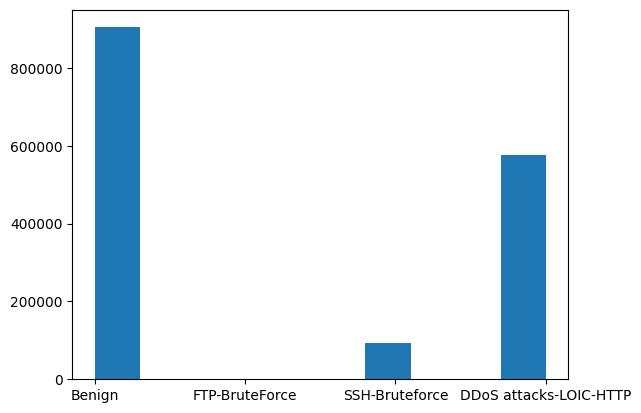

In [ ]:
#representation de classe
plt.hist(df_all['Label'])
plt.show()

on remarque **un déséquilibre** extrême sur la classe FTP-BruteForce : seulement 53 exemples sur 1.57 million de lignes. C'est un vrai problème pour la suite.

la solution consiste a **Supprimer** la classe **FTP-BruteForce**
La retirer complètement car trop peu représentée pour être exploitable statistiquement.

In [47]:
# Supprimer les lignes FTP-BruteForce
df_all = df_all[df_all['Label'] != 'FTP-BruteForce'].reset_index(drop=True)

# Vérification
print(df_all.shape)
df_all['Label'].value_counts()

(1562127, 78)


Label
Benign                    892715
DDoS attacks-LOIC-HTTP    575364
SSH-Bruteforce             94048
Name: count, dtype: int64

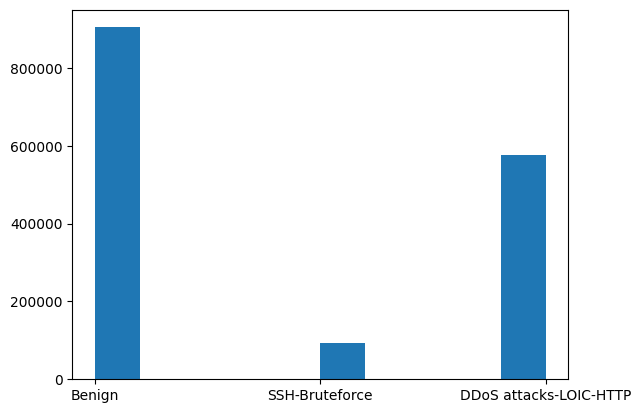

In [ ]:
#representation de classe
plt.hist(df_all['Label'])
plt.show()

on va retourner au probleme de déséquilibrement dans une section apres

---



In [ ]:
# afficher des informations sur tout le dataframe
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1574139 entries, 0 to 1574138
Data columns (total 78 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Protocol                  1574139 non-null  int8   
 1   Flow Duration             1574139 non-null  int64  
 2   Total Fwd Packets         1574139 non-null  int32  
 3   Total Backward Packets    1574139 non-null  int16  
 4   Fwd Packets Length Total  1574139 non-null  int32  
 5   Bwd Packets Length Total  1574139 non-null  int32  
 6   Fwd Packet Length Max     1574139 non-null  int32  
 7   Fwd Packet Length Min     1574139 non-null  int16  
 8   Fwd Packet Length Mean    1574139 non-null  float32
 9   Fwd Packet Length Std     1574139 non-null  float32
 10  Bwd Packet Length Max     1574139 non-null  int16  
 11  Bwd Packet Length Min     1574139 non-null  int16  
 12  Bwd Packet Length Mean    1574139 non-null  float32
 13  Bwd Packet Length Std     1

In [ ]:
#retourner les colonnes numeriques
df_numeric = df_all.select_dtypes(include="number").columns
print(df_all.select_dtypes(include="number").columns)
print("nombre des colonnes numeriques : ",df_all.select_dtypes(include="number").columns.size)
df_numeric

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Fla

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Fla

In [ ]:
#retourner les colonnes de type object
df_object = df_all.select_dtypes(include="object").columns
print(df_object)
print("nombre des colonnes de type object : ",df_all.select_dtypes(include="object").columns.size)


Index(['Label'], dtype='object')
nombre des colonnes de type object :  1


In [ ]:
#nombre des valeur NaN
print("nombre des valeur NaN : ",df_all.isna().sum().sum())

nombre des valeur NaN :  0


In [ ]:
#taille du dataframe
print("taille du dataframe : ", df_all.shape)

taille du dataframe :  (1574139, 78)


cette dataset bien nettoye ne contient pas des valeurs **NaN (valeurs manquantes)**

In [ ]:
#identifier les doublons
# Series booléenne : True = ligne dupliquée
mask_doublons = df_all.duplicated()
print(mask_doublons)
# Filtrer df_all avec ce masque pour voir les lignes concernées
lignes_doublons = df_all[mask_doublons]
print(lignes_doublons.shape)
lignes_doublons

0          False
1          False
2          False
3          False
4          False
           ...  
1574134    False
1574135    False
1574136    False
1574137    False
1574138    False
Length: 1574139, dtype: bool
(12012, 78)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
1044553,6,20,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1045842,6,8,1,1,0,0,0,0,0.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1048558,6,10,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1049286,6,5,1,1,0,0,0,0,0.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1051817,6,20,1,1,0,0,0,0,0.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573461,6,1014,3,0,77,0,46,0,25.666666,23.459185,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1573697,6,213,3,0,77,0,46,0,25.666666,23.459185,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1573988,17,928,1,1,38,103,38,38,38.000000,0.000000,...,8,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1574043,6,131,2,0,0,0,0,0,0.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


Supprimer les doublons

In [46]:
df_all = df_all.drop_duplicates().reset_index(drop=True)
print(df_all.shape)
df_all['Label'].value_counts()

(1562180, 78)


Label
Benign                    892715
DDoS attacks-LOIC-HTTP    575364
SSH-Bruteforce             94048
FTP-BruteForce                53
Name: count, dtype: int64

In [ ]:
df_all

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,112641719,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56320860.0,139.300034,56320958,56320761,Benign
1,0,112641466,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56320732.0,114.551300,56320814,56320652,Benign
2,0,112638623,3,0,0,0,0,0,0.000000,0.000000,...,0,0.0,0.0,0,0,56319312.0,301.934601,56319525,56319098,Benign
3,6,6453966,15,10,1239,2273,744,0,82.599998,196.741241,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,6,8804066,14,11,1143,2209,744,0,81.642860,203.745544,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562122,17,305,1,1,41,121,41,41,41.000000,0.000000,...,8,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
1562123,6,5128650,9,7,597,4752,342,0,66.333336,122.971542,...,20,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
1562124,6,5129181,9,7,597,4752,342,0,66.333336,122.971542,...,20,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
1562125,6,5129544,9,7,597,4752,342,0,66.333336,122.971542,...,20,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


In [50]:
df_all.to_parquet(r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\archive (1)\clean_simple.parquet")

# Encodage, Train/Test Split, Scaling, SMOTE




Objectif de ce notebook :
1. Chargement du dataset avec features selectionnees
2. Encodage des labels (etape 3)
3. Train/Test split stratifie (etape 4)
4. Scaling Standard/MinMax (etape 5)
5. SMOTE sur le train uniquement (etape 6)
6. Verifications finales
7. Sauvegarde des donnees pretes pour la modelisation 



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import joblib

In [3]:
!pip install imbalanced-learn

In [34]:
import re 
df_selected = pd.read_parquet(r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\v1\df_selected.parquet")
df_selected.head(5)

,Protocol,Flow Duration,Fwd Packet Length Max,Fwd Packet Length Mean,Bwd Packet Length Min,Flow Bytes/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Fwd IAT Std,...,Subflow Fwd Bytes,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Idle Std,Idle Min,Label
0,6,888751,736,113.545456,0,3620.811678,4.232148e+04,47851.734375,101609,49295.734375,...,1249,14600,233,32,0.0,0.0,0,0.000000,0,Benign
1,0,112642816,0,0.000000,0,0.000000,5.630000e+07,7.071068,56300000,7.071068,...,0,-1,-1,0,0.0,0.0,0,7.071068,56300000,Benign
2,0,112642712,0,0.000000,0,0.000000,5.630000e+07,18.384777,56300000,18.384777,...,0,-1,-1,0,0.0,0.0,0,18.384777,56300000,Benign
3,0,112642648,0,0.000000,0,0.000000,5.630000e+07,5.656854,56300000,5.656854,...,0,-1,-1,0,0.0,0.0,0,5.656854,56300000,Benign
4,0,112642702,0,0.000000,0,0.000000,5.630000e+07,65.053825,56300000,65.053825,...,0,-1,-1,0,0.0,0.0,0,65.053825,56300000,Benign


In [36]:
import json
feature_names = df_selected.drop(columns=['Label']).columns.tolist()

with open(r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\feature_names.json", "w") as f:
    json.dump(feature_names, f)

print("Nombre de features:", len(feature_names))

Nombre de features: 36


In [9]:
shape = df_selected.shape
shape

(1574187, 37)

In [10]:
df_selected['Label'].value_counts()

Label
Benign                    904722
DDoS attacks-LOIC-HTTP    575364
SSH-Bruteforce             94048
FTP-BruteForce                53
Name: count, dtype: int64

## **Supprimer FTP-BruteForce**

In [11]:
# Supprimer les lignes FTP-BruteForce
df_selected = df_selected[df_selected['Label'] != 'FTP-BruteForce'].reset_index(drop=True)

# Vérification
print(df_selected.shape)
df_selected['Label'].value_counts()

(1574134, 37)


Label
Benign                    904722
DDoS attacks-LOIC-HTTP    575364
SSH-Bruteforce             94048
Name: count, dtype: int64

Ce n'est pas un déséquilibre extrême (comme le cas FTP-BruteForce à 53 exemples), mais c'est bien un déséquilibre modéré : SSH-Bruteforce reste 6 à 10 fois moins représentée que les deux autres classes. Ce niveau de déséquilibre est très courant en cybersécurité (par nature, les attaques sont plus rares que le trafic normal) et reste gérable, contrairement à FTP-BruteForce qui était statistiquement inexploitable.


In [17]:
le = LabelEncoder()

y = le.fit_transform(df_selected['Label'])
X = df_selected.drop(columns=['Label'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping des classes :")
for classe, code_num in label_mapping.items():
    print(f"  {code_num} -> {classe}")

joblib.dump(le, r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\label_encoder.pkl")
print("\nLabelEncoder sauvegarde : label_encoder.pkl")


Mapping des classes :
  0 -> Benign
  1 -> DDoS attacks-LOIC-HTTP
  2 -> SSH-Bruteforce

LabelEncoder sauvegarde : label_encoder.pkl


In [52]:
le = LabelEncoder()

y = le.fit_transform(df_all['Label'])
X = df_all.drop(columns=['Label'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping des classes :")
for classe, code_num in label_mapping.items():
    print(f"  {code_num} -> {classe}")

joblib.dump(le, r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\df_all_label_encoder.pkl")
print("\nLabelEncoder sauvegarde : df_all_label_encoder.pkl")

Mapping des classes :
  0 -> Benign
  1 -> DDoS attacks-LOIC-HTTP
  2 -> SSH-Bruteforce

LabelEncoder sauvegarde : df_all_label_encoder.pkl


---
Le choix d'un `LabelEncoder` plutot qu'un `OneHotEncoder` sur la variable cible se justifie par la nature multi-classe (et non multi-label) du probleme : chaque observation appartient a une seule classe. Les algorithmes utilises par la suite (Random Forest, XGBoost, regression logistique multinomiale) prennent nativement en charge des labels entiers pour la classification multi-classe, ce qui rend un encodage one-hot de la cible inutile et couteux en memoire. Le LabelEncoder est sauvegarde afin de garantir la coherence du mapping classe/entier entre l'entrainement, l'evaluation et la future API de prediction .

## 3. Train/Test Split stratifie 
stratify=y :

Pandas/sklearn garantit que chaque classe garde exactement la même proportion dans train et test qu'elle avait dans le dataset original. Si SSH-Bruteforce représente 6% du dataset total, elle représentera 6% du train ET 6% du test, garanti.

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")

print("\nDistribution train :")
train_dist = pd.Series(y_train).value_counts().sort_index()
train_dist.index = le.inverse_transform(train_dist.index)
print(train_dist)

print("\nDistribution test :")
test_dist = pd.Series(y_test).value_counts().sort_index()
test_dist.index = le.inverse_transform(test_dist.index)
print(test_dist)

Train : 1249701 lignes
Test  : 312426 lignes

Distribution train :
Benign                    714172
DDoS attacks-LOIC-HTTP    460291
SSH-Bruteforce             75238
Name: count, dtype: int64

Distribution test :
Benign                    178543
DDoS attacks-LOIC-HTTP    115073
SSH-Bruteforce             18810
Name: count, dtype: int64


In [51]:
df_all.shape

(1562127, 78)

## 4. Scaling Standard/MinMax (etape 5)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit UNIQUEMENT sur le train (jamais sur le test, sinon fuite de données)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Sauvegarde du scaler pour la Phase 2 (déploiement)
import joblib
joblib.dump(scaler, r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\df_all_scaler.pkl")
print("Scaler sauvegardé.")

Scaler sauvegardé.


## Sans Smote

## Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import time

# Entraînement
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    max_features='sqrt', 
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # utilise tous les cœurs CPU disponibles pour accélérer
)

start = time.time()
model.fit(X_train_scaled, y_train)
print(f"Temps d'entraînement : {time.time() - start:.2f} sec")

Temps d'entraînement : 151.48 sec


## Prédiction et évaluation

=== Random forest ===
Accuracy: 0.9983
Precision (macro): 0.9985
Recall (macro): 0.999
F1-score (macro): 0.9987
AUC (OvR macro): 1.0
MCC: 0.9968

--- Classification Report détaillé ---
                        precision    recall  f1-score   support

                Benign       1.00      1.00      1.00    180944
DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115073
        SSH-Bruteforce       1.00      1.00      1.00     18810

              accuracy                           1.00    314827
             macro avg       1.00      1.00      1.00    314827
          weighted avg       1.00      1.00      1.00    314827



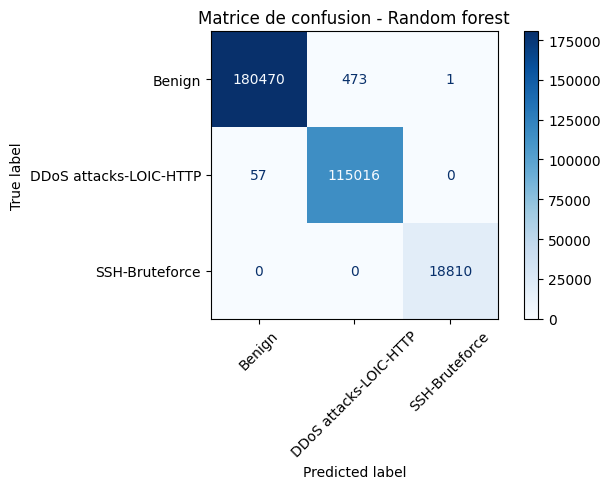

In [6]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

# Appel de la fonction d'évaluation
res_dt = evaluer_modele(
    y_true=y_test,
    y_pred=y_pred,
    y_proba=y_proba,
    nom_modele="Random forest",
    classes=le.classes_
)

In [7]:
# ============ Sauvegarde du modèle (optionnel, pour comparaison finale) ============
import joblib
joblib.dump(model, r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\model_Random_forest.pkl")
print("\nModèle sauvegardé : model_Random_forest.pkl")


Modèle sauvegardé : model_Random_forest.pkl


## Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import time

# ============ Entraînement ============
model_lr = LogisticRegression(
    multi_class='multinomial',
    class_weight='balanced',
    max_iter=1000,
    n_jobs=-1,
    random_state=42
)

start = time.time()
model_lr.fit(X_train_scaled, y_train)
print(f"Temps d'entraînement: {time.time() - start:.2f} sec")

C:\Users\21276\anaconda3\envs\tf_bert\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Temps d'entraînement: 70.14 sec


=== Logistic Regression ===
Accuracy: 0.9894
Precision (macro): 0.9885
Recall (macro): 0.9939
F1-score (macro): 0.9911
AUC (OvR macro): 0.9993
MCC: 0.9805

--- Classification Report détaillé ---
                        precision    recall  f1-score   support

                Benign       1.00      0.98      0.99    180944
DDoS attacks-LOIC-HTTP       0.97      1.00      0.99    115073
        SSH-Bruteforce       0.99      1.00      1.00     18810

              accuracy                           0.99    314827
             macro avg       0.99      0.99      0.99    314827
          weighted avg       0.99      0.99      0.99    314827



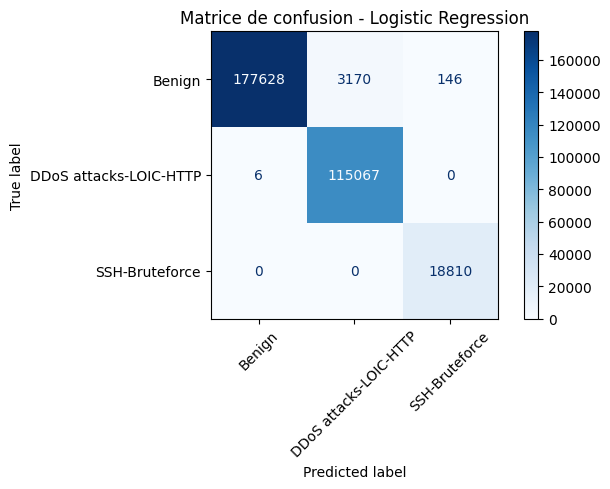

In [9]:
# ============ Prédiction ============
y_pred_lr = model_lr.predict(X_test_scaled)
y_proba_lr= model_lr.predict_proba(X_test_scaled)

# Appel de la fonction d'évaluation
res_dt = evaluer_modele(
    y_true=y_test,
    y_pred=y_pred_lr,
    y_proba=y_proba_lr,
    nom_modele="Logistic Regression",
    classes=le.classes_
)

In [10]:
# ============ Sauvegarde du modèle (optionnel, pour comparaison finale) ============
import joblib
joblib.dump(model_lr, r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\model_logistic_regression.pkl")
print("\nModèle sauvegardé : model_logistic_regression.pkl")


Modèle sauvegardé : model_logistic_regression.pkl


In [1]:
import numpy as np
import joblib

X_train_scaled = np.load(r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\X_train.npy")
X_test_scaled = np.load(r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\X_test.npy")
y_train = np.load(r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\y_train.npy")
y_test = np.load(r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\y_test.npy")

scaler = joblib.load(r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\Project_with_tree_file\scaler.pkl")
le = joblib.load(r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\label_encoder.pkl")

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("Classes:", le.classes_)

X_train_scaled: (1259307, 36)
X_test_scaled: (314827, 36)
Classes: ['Benign' 'DDoS attacks-LOIC-HTTP' 'SSH-Bruteforce']


## Decision Tree 

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import time

# ============ Entraînement ============
model_dt = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=10,
    random_state=42
)

start = time.time()
model_dt.fit(X_train_scaled, y_train)
print(f"Temps d'entraînement: {time.time() - start:.2f} sec")

Temps d'entraînement: 30.69 sec


In [29]:
# ============ Prédiction ============
y_pred_dt = model_dt.predict(X_test_scaled)

## fonction d'evaluation avec 6 metriques

In [2]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

def evaluer_modele(y_true, y_pred, y_proba, nom_modele, classes):
    """
    Calcule Accuracy, Precision/Recall/F1 (macro), AUC (OvR macro), et MCC.
    
    y_true  : labels réels (encodés, ex: y_test)
    y_pred  : labels prédits (ex: model.predict(X_test_scaled))
    y_proba : probabilités prédites, shape (n_samples, n_classes) 
              -> model.predict_proba(X_test_scaled)
    nom_modele : string, pour l'affichage
    classes : liste des noms de classes (ex: le.classes_)
    """
    
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc_macro = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    mcc = matthews_corrcoef(y_true, y_pred)
    
    resultats = {
        'Modèle': nom_modele,
        'Accuracy': round(accuracy, 4),
        'Precision (macro)': round(precision_macro, 4),
        'Recall (macro)': round(recall_macro, 4),
        'F1-score (macro)': round(f1_macro, 4),
        'AUC (OvR macro)': round(auc_macro, 4),
        'MCC': round(mcc, 4)
    }
    
    print(f"=== {nom_modele} ===")
    for k, v in resultats.items():
        if k != 'Modèle':
            print(f"{k}: {v}")
    
    print("\n--- Classification Report détaillé ---")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(f"Matrice de confusion - {nom_modele}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return resultats

=== Decision Tree ===
Accuracy: 0.9993
Precision (macro): 0.9993
Recall (macro): 0.9996
F1-score (macro): 0.9994
AUC (OvR macro): 0.9996
MCC: 0.9986

--- Classification Report détaillé ---
                        precision    recall  f1-score   support

                Benign       1.00      1.00      1.00    180944
DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    115073
        SSH-Bruteforce       1.00      1.00      1.00     18810

              accuracy                           1.00    314827
             macro avg       1.00      1.00      1.00    314827
          weighted avg       1.00      1.00      1.00    314827



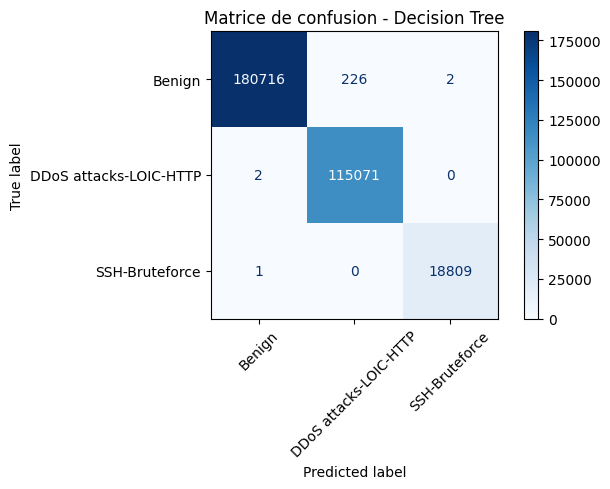

In [30]:
# Prédictions + probabilités
#y_pred_dt = model_dt.predict(X_test_scaled)
y_proba_dt = model_dt.predict_proba(X_test_scaled)

# Appel de la fonction d'évaluation
res_dt = evaluer_modele(
    y_true=y_test,
    y_pred=y_pred_dt,
    y_proba=y_proba_dt,
    nom_modele="Decision Tree",
    classes=le.classes_
)

In [31]:
# ============ Sauvegarde du modèle ============
import joblib
joblib.dump(model_dt, r"C:\Users\21276\Desktop\master Fp\s2\Cloud_compputing\Projet-cloud\Project_with_tree_file\model_dt.pkl")
print("\nModèle sauvegardé : model_xgboost.pkl")


Modèle sauvegardé : model_xgboost.pkl


## SVM

In [16]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

model_svm = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
model_svm.fit(X_train_scaled, y_train)

LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)

Accuracy          : 0.9896
Precision (macro) : 0.9877
Recall (macro)    : 0.9935
F1-score (macro)  : 0.9905
MCC               : 0.9807

=== Classification Report détaillé ===
                        precision    recall  f1-score   support

                Benign       1.00      0.98      0.99    180944
DDoS attacks-LOIC-HTTP       0.97      1.00      0.99    115073
        SSH-Bruteforce       0.99      1.00      0.99     18810

              accuracy                           0.99    314827
             macro avg       0.99      0.99      0.99    314827
          weighted avg       0.99      0.99      0.99    314827



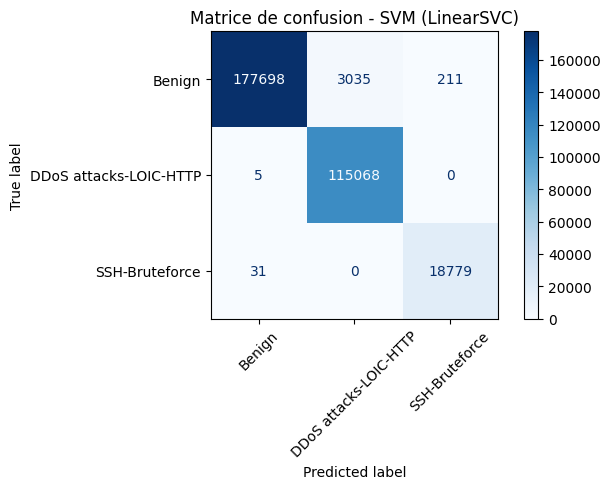

In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Prédiction (rapide, pas besoin de proba)
y_pred_svm = model_svm.predict(X_test_scaled)

# Calcul direct des métriques
accuracy = accuracy_score(y_test, y_pred_svm)
precision_macro = precision_score(y_test, y_pred_svm, average='macro', zero_division=0)
recall_macro = recall_score(y_test, y_pred_svm, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred_svm, average='macro', zero_division=0)
mcc = matthews_corrcoef(y_test, y_pred_svm)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision (macro) : {precision_macro:.4f}")
print(f"Recall (macro)    : {recall_macro:.4f}")
print(f"F1-score (macro)  : {f1_macro:.4f}")
print(f"MCC               : {mcc:.4f}")

print("\n=== Classification Report détaillé ===")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Matrice de confusion - SVM (LinearSVC)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
import numpy as np
from sklearn.metrics import roc_auc_score

decision_scores = model_svm.decision_function(X_test_scaled)  # shape (n_samples, n_classes)

# Conversion en pseudo-probabilités via softmax
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))  # stabilité numérique
    return e_x / e_x.sum(axis=1, keepdims=True)

y_proba_svm_approx = softmax(decision_scores)

# Vérification : chaque ligne doit sommer à 1
print("Somme ligne 0 :", y_proba_svm_approx[0].sum())  # doit être ~1.0

auc_macro = roc_auc_score(y_test, y_proba_svm_approx, multi_class='ovr', average='macro')
print(f"AUC (OvR macro) : {auc_macro:.4f}")

Somme ligne 0 : 0.9999999999999999
AUC (OvR macro) : 0.9994
